<a href="https://colab.research.google.com/github/okaisank/IT-Stou/blob/main/LoRA_Generate_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CELL 1: ติดตั้งไลบรารี

In [45]:
!pip uninstall -y torchao protobuf
!pip install -q "protobuf==5.29.5"
!pip install -q -U diffusers transformers accelerate peft safetensors sentencepiece huggingface_hub

Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5


## CELL 2 — Restart Runtime

In [ ]:
import os
os.kill(os.getpid(), 9)

## CELL 2: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## CELL 3: ตั้งค่า Path LoRA

In [2]:
import os

LORA_PATH = "/content/drive/MyDrive/16-LoRA Generate Image/JoeVohan.safetensors"

if not os.path.exists(LORA_PATH):
    raise FileNotFoundError(f"ไม่พบไฟล์ LoRA: {LORA_PATH}")

print("พบไฟล์ LoRA:", LORA_PATH)
print("ขนาดไฟล์:", round(os.path.getsize(LORA_PATH) / (1024 * 1024), 2), "MB")

พบไฟล์ LoRA: /content/drive/MyDrive/16-LoRA Generate Image/JoeVohan.safetensors
ขนาดไฟล์: 18.38 MB


## CELL 4: Login Hugging Face


In [3]:
from huggingface_hub import login

login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## CELL 3: Upload รูปต้นแบบ

In [148]:
from google.colab import files
uploaded = files.upload()

input_name = list(uploaded.keys())[0]
input_path = "/content/" + input_name

print("input_path =", input_path)

Saving B6FtNKtgSqRqbnNsbGBwjQUiUxzcNnD9EHH5cS6m35IEreRspJA3rJkYn9b2BULNVWulo.jpg to B6FtNKtgSqRqbnNsbGBwjQUiUxzcNnD9EHH5cS6m35IEreRspJA3rJkYn9b2BULNVWulo.jpg
input_path = /content/B6FtNKtgSqRqbnNsbGBwjQUiUxzcNnD9EHH5cS6m35IEreRspJA3rJkYn9b2BULNVWulo.jpg


## CELL 4: โหลด FLUX Img2Img + LoRA

In [149]:
import os
import gc
import torch
from PIL import Image
from diffusers import FluxImg2ImgPipeline

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
torch.cuda.empty_cache()

BASE_MODEL = "black-forest-labs/FLUX.1-schnell"

pipe = FluxImg2ImgPipeline.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

pipe.enable_sequential_cpu_offload()
pipe.enable_vae_slicing()
pipe.enable_vae_tiling()

print("โหลด FLUX Img2Img สำเร็จ")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

โหลด FLUX Img2Img สำเร็จ


## CELL 6: โหลด LoRA

In [150]:
import os

LORA_DIR = "/content/drive/MyDrive/16-LoRA Generate Image"
LORA_NAME = "JoeVohan.safetensors"
LORA_PATH = os.path.join(LORA_DIR, LORA_NAME)

if not os.path.exists(LORA_PATH):
    raise FileNotFoundError(f"ไม่พบไฟล์ LoRA: {LORA_PATH}")

# ถ้าเคยโหลด LoRA เดิมแล้ว ให้ unload ก่อน ป้องกันซ้ำ
try:
    pipe.unload_lora_weights()
    print("ล้าง LoRA เดิมแล้ว")
except:
    print("ยังไม่มี LoRA เดิม หรือ unload ไม่จำเป็น")

pipe.load_lora_weights(
    LORA_DIR,
    weight_name=LORA_NAME,
    adapter_name="joevohan_lora"
)

# แนะนำเริ่มที่ 0.6 เพื่อความ realistic
pipe.set_adapters(
    ["joevohan_lora"],
    adapter_weights=[0.8]
)

print("โหลด LoRA สำเร็จ")
print("LoRA weight = 0.8")

ล้าง LoRA เดิมแล้ว


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


โหลด LoRA สำเร็จ
LoRA weight = 0.8


##

## CELL 7: Run LoRA

  0%|          | 0/2 [00:00<?, ?it/s]

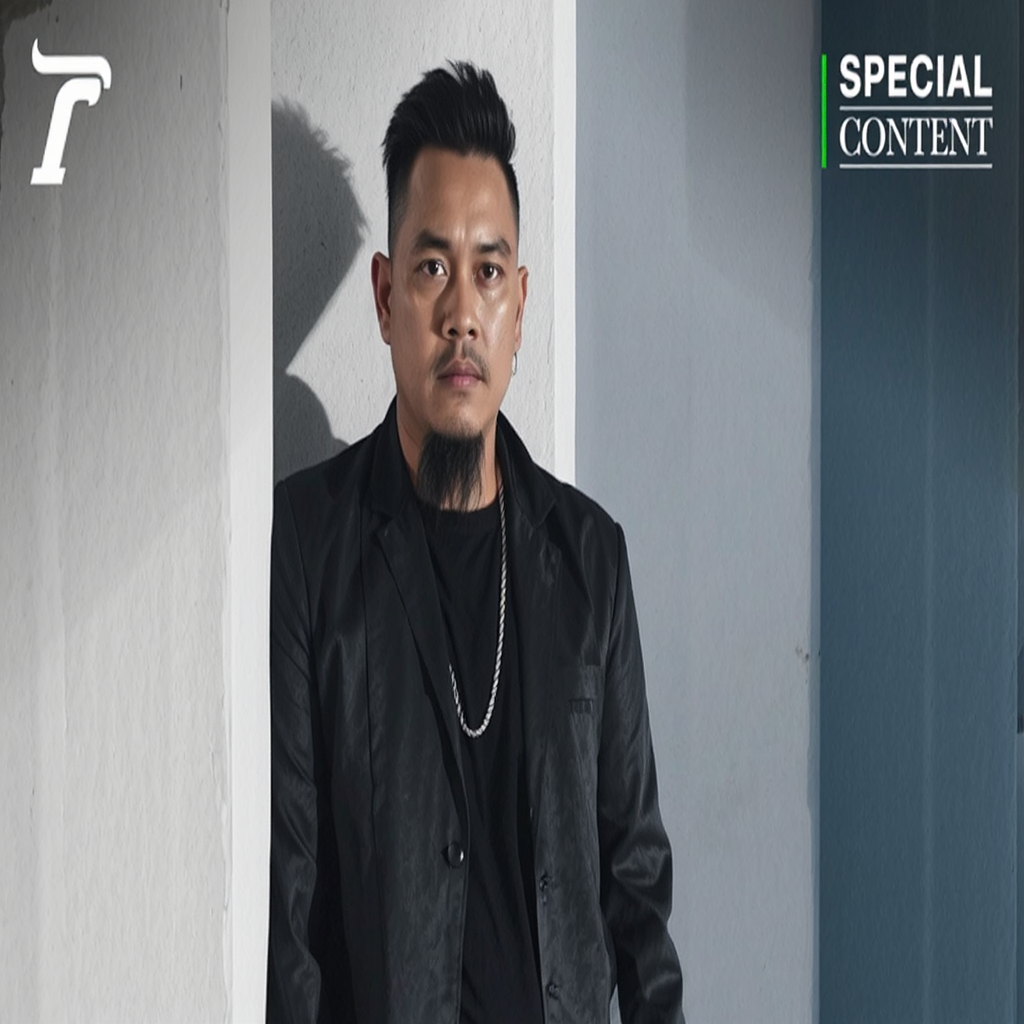

In [158]:
import gc
import torch
from PIL import Image

gc.collect()
torch.cuda.empty_cache()

init_image = Image.open(input_path).convert("RGB")
init_image = init_image.resize((684, 384))   # เปลี่ยนจาก (384,512)

prompt = """
joevohan, joevohan face identity, photorealistic portrait of a Thai man,
realistic skin texture, natural face proportions, sharp eyes, detailed face,
clean short black hair, candid portrait photo, natural daylight,
high detail, realistic photography, natural colors, sharp focus
"""

image = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.30,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=128,
    generator=torch.Generator("cpu").manual_seed(2233)
).images[0]

image

## CELL 8: บันทึกและดาวน์โหลด

In [159]:
output_path = "/content/joevohan_lora_test.png"
image.save(output_path)

from google.colab import files
files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>